<a href="https://colab.research.google.com/github/ClassNeuralNetwork/classification-fatigue-detection/blob/main/Deteccao_Sonolencia_MobileNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import tensorflow as tf
import os
import cv2
import random
from tqdm.notebook import tqdm

from numpy.random import shuffle
import numpy as np
import pandas as pd
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.applications.mobilenet import preprocess_input
from tensorflow.keras.applications import MobileNet
from matplotlib import pyplot as plt
from tensorflow.keras.models import Model

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("serenaraju/yawn-eye-dataset-new")

Using Colab cache for faster access to the 'yawn-eye-dataset-new' dataset.


In [6]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

DATASET = os.path.join(path, "dataset_new")
TRAIN_DIR = os.path.join(DATASET, "train")
TEST_DIR = os.path.join(DATASET, "test")

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASS = len(CLASS_NAMES)
print(f"Classes ({NUM_CLASS}): {CLASS_NAMES}")

Classes (4): ['Closed', 'Open', 'no_yawn', 'yawn']


In [4]:
# train_ds = tf.keras.preprocessing.image_dataset_from_directory(
#     TRAIN_DIR,
#     seed = SEED,
#     image_size = IMAGE_SIZE,
#     batch_size = BATCH_SIZE
# )

# test_ds = tf.keras.preprocessing.image_dataset_from_diimreadrectory(
#     TEST_DIR,
#     seed = SEED,
#     image_size = IMAGE_SIZE,
#     batch_size = BATCH_SIZE
# )

In [7]:
def load_image(directory):
  images = []
  labels = []

  for category in os.listdir(directory):
    for filename in tqdm(os.listdir(directory+category)):
      image_path = os.path.join(directory+category, filename)

      img = cv2.imread(image_path)
      img = cv2.resize(img, IMAGE_SIZE)
      images.append(img)
      labels.append(category)

  images = np.array(images, dtype='float32')
  return images, labels

print("Treino")
train_ds = load_image(DATASET + '/train/')
print("Teste")
test_ds = load_image(DATASET + '/test/')

Treino


  0%|          | 0/617 [00:00<?, ?it/s]

  0%|          | 0/617 [00:00<?, ?it/s]

  0%|          | 0/617 [00:00<?, ?it/s]

  0%|          | 0/616 [00:00<?, ?it/s]

Teste


  0%|          | 0/109 [00:00<?, ?it/s]

  0%|          | 0/109 [00:00<?, ?it/s]

  0%|          | 0/106 [00:00<?, ?it/s]

  0%|          | 0/109 [00:00<?, ?it/s]

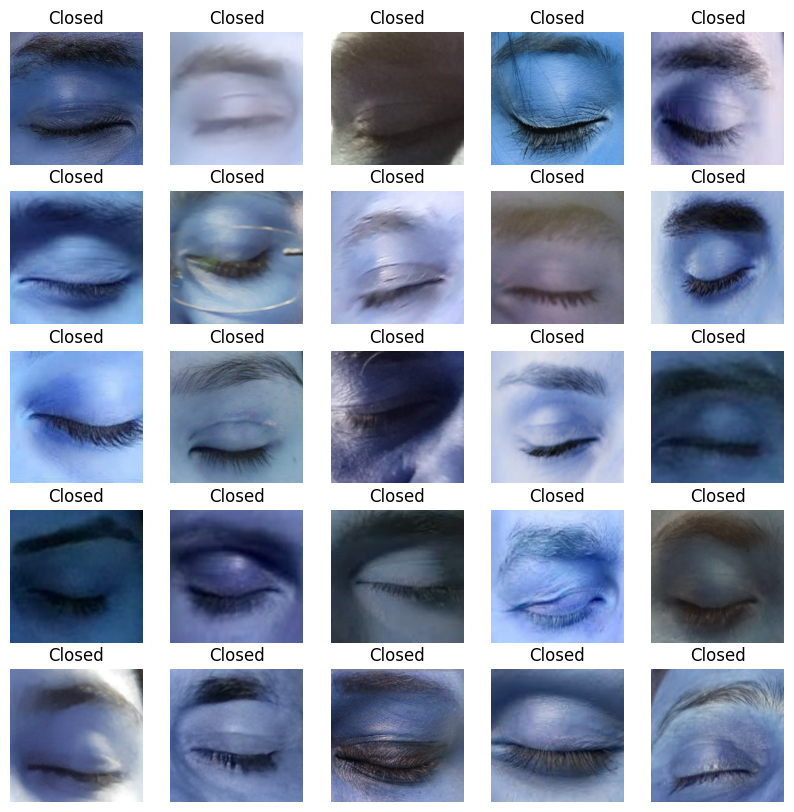

In [8]:
plt.figure(figsize = (10, 10))
images, labels = train_ds

for i in range(min(25, len(images))):
    ax = plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(images[i].astype("uint8"))
    plt.title(labels[i])
    plt.axis("off")
plt.show()

In [9]:
model = MobileNet(
  input_shape=(*IMAGE_SIZE, 3),
  include_top=False,
  weights="imagenet",
  pooling='avg',
  name="Sonolencia",
)

# for layer in model.layers:
#   layer.trainable = True

x = model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)
model_transfer = Model(inputs=model.input, outputs=predictions)
model_transfer.summary()

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,492,292 (13.32 MB)

 Trainable params: 3,470,404 (13.24 MB)

 Non-trainable params: 21,888 (85.50 KB)

In [8]:
model_transfer.save('model_transfer.h5')

In [10]:
model_transfer.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])